In [1]:
import numpy as np 
import pandas as pd 

In [2]:
df=pd.read_csv(r"C:\Users\Moussab\Downloads\Airline_review.csv (1)\Airline_review.csv")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

In [3]:
pd.set_option('display.max_columns',None)
df.head(3)

,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no


In [4]:
df1 = df[["Review", "Recommended"]].copy()
df1["Recommended"] = df1["Recommended"].map({"yes": 1, "no": 0})


## 2. Exploratory Data Analysis (EDA)

In [5]:
df1.isna().sum()

Review         0
Recommended    0
dtype: int64

In [13]:
# Most ratings are negative
df1['Recommended'].mean()

np.float64(0.33692978291830306)

C:\Users\Moussab\AppData\Local\Temp\ipykernel_11932\2360334954.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='magma')


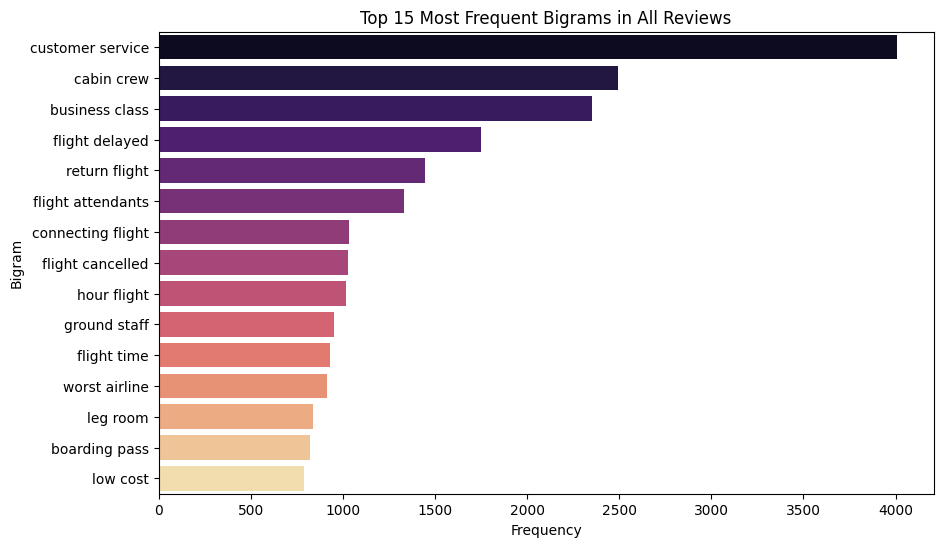

In [21]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import seaborn as sns

vec = CountVectorizer(ngram_range=(2, 2), stop_words='english')
bow = vec.fit_transform(df1['Review'])

sum_words = bow.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:15]

df_bigrams = pd.DataFrame(words_freq, columns=['Bigram', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Bigram', data=df_bigrams, palette='magma')
plt.title('Top 15 Most Frequent Bigrams in All Reviews')
plt.show()

C:\Users\Moussab\AppData\Local\Temp\ipykernel_11932\948475795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df1, x='Recommended', palette='viridis')


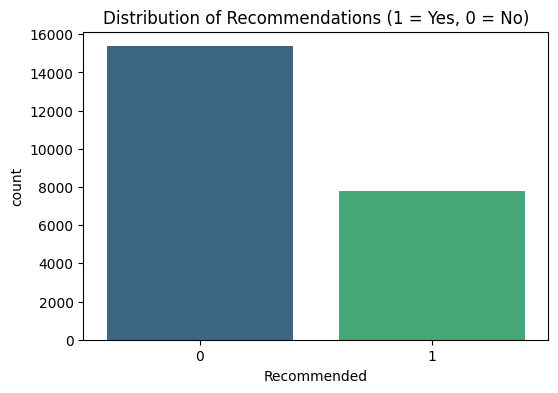

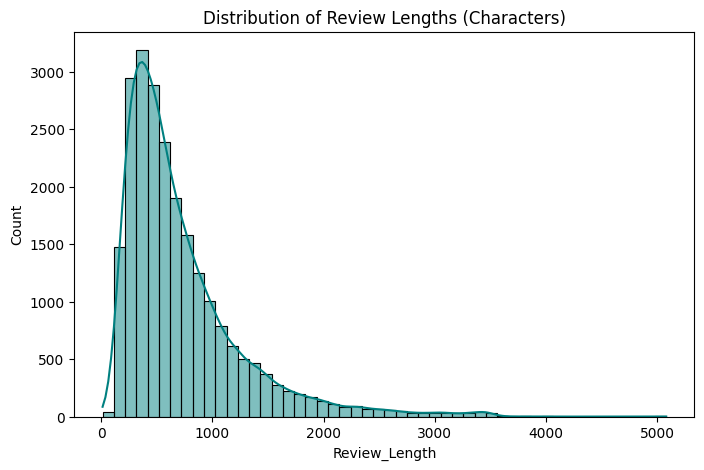

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df1, x='Recommended', palette='viridis')
plt.title('Distribution of Recommendations (1 = Yes, 0 = No)')
plt.show()

df1['Review_Length'] = df1['Review'].astype(str).apply(len)
plt.figure(figsize=(8, 5))
sns.histplot(data=df1, x='Review_Length', bins=50, kde=True, color='teal')
plt.title('Distribution of Review Lengths (Characters)')
plt.show()

## 3. Text Preprocessing

In [7]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import re
import string

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", " ", text)  
    text = re.sub(r"\s+", " ", text).strip()  
    return text

def lemmatize_text(text):
    words = word_tokenize(text)  
    lemmatized_text = " ".join([lemmatizer.lemmatize(word) for word in words if word not in stop_words])
    return lemmatized_text

df1['Review'] = [clean_text(text) for text in df1['Review']]

## 4. Modeling
### Model 1: Base Logistic Regression (Bag of Words)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df1['Review'], 
                                                    df1['Recommended'], 
                                                    random_state=0)

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer().fit(X_train)
len(vect.get_feature_names_out())

29828

In [18]:
X_train_vectorized = vect.transform(X_train)

X_train_vectorized

<17378x29828 sparse matrix of type '<class 'numpy.int64'>'
	with 1415397 stored elements in Compressed Sparse Row format>

In [19]:
from sklearn.linear_model import LogisticRegression

# Train the model
model = LogisticRegression()
model.fit(X_train_vectorized, y_train)

c:\Users\Moussab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [20]:
from sklearn.metrics import roc_auc_score

# Predict the transformed test documents
predictions = model.predict(vect.transform(X_test))

print('AUC: ', roc_auc_score(y_test, predictions))

AUC:  0.8768855968079926


### Model 2: Logistic Regression (TF-IDF)

In [21]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Fit the TfidfVectorizer to the training data specifiying a minimum document frequency of 5
vect = TfidfVectorizer(min_df=5).fit(X_train)

In [22]:
X_train_vectorized = vect.transform(X_train)

model = LogisticRegression()
model.fit(X_train_vectorized, y_train)

predictions = model.predict(vect.transform(X_test))

print('AUC: ', roc_auc_score(y_test, predictions))

AUC:  0.8830862508731452


### Model 3: Logistic Regression (N-Grams 1-3)

In [23]:
vect = CountVectorizer(min_df=5, ngram_range=(1,3)).fit(X_train)

X_train_vectorized = vect.transform(X_train)
model = LogisticRegression()
model.fit(X_train_vectorized, y_train)

predictions = model.predict(vect.transform(X_test))

print('AUC: ', roc_auc_score(y_test, predictions))


AUC:  0.8919265155684439


### Model 4: XGBoost Classifier

In [24]:
import xgboost as xgb

xgb_cl = xgb.XGBClassifier(eval_metric='mlogloss')
xgb_cl.fit(X_train_vectorized, y_train)
predictions = xgb_cl.predict(vect.transform(X_test))
print('AUC: ', roc_auc_score(y_test, predictions))


AUC:  0.8785576699193531


## 5. Model Comparison & Conclusion

C:\Users\Moussab\AppData\Local\Temp\ipykernel_11932\896863974.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(auc_scores.keys()), y=list(auc_scores.values()), palette='mako')


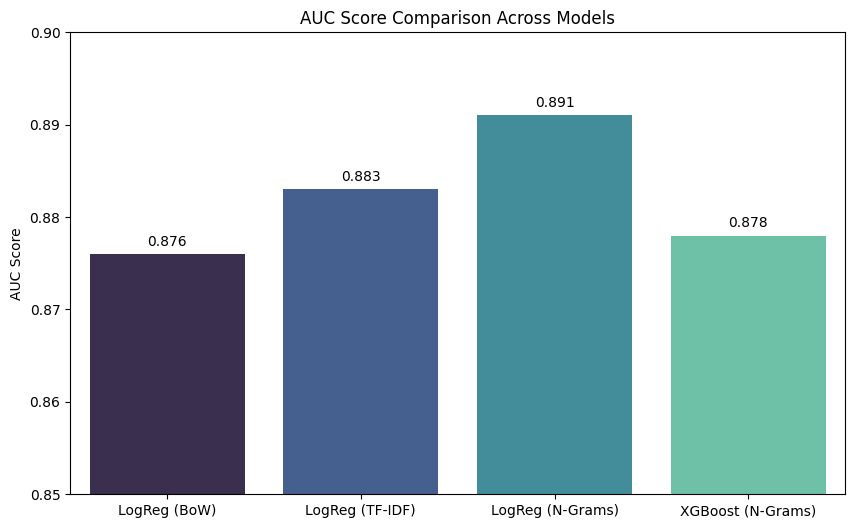

In [9]:
auc_scores = {
    'LogReg (BoW)': 0.876,
    'LogReg (TF-IDF)': 0.883,
    'LogReg (N-Grams)': 0.891,
    'XGBoost (N-Grams)': 0.878
}

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(auc_scores.keys()), y=list(auc_scores.values()), palette='mako')
plt.ylim(0.85, 0.90)
plt.title('AUC Score Comparison Across Models')
plt.ylabel('AUC Score')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()